<a href="https://colab.research.google.com/github/swewak/comp_math/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%966_%D0%A4%D0%BE%D1%80%D0%BC%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D1%8D%D0%BB%D0%B5%D0%BA%D1%82%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%82%D0%B0%D0%B1%D0%BB%D0%B8%D1%86.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №6. Формирование электронных таблиц. Многопоточная и многопроцессорная оптимизация. Работа с генераторами

# Теоретическая часть

## 1. Генераторы в Python

**Генератор данных** - это специальный вид функции в Python, который позволяет создавать последовательность значений по мере необходимости. Вместо того чтобы сразу генерировать и хранить все значения, генератор создает их по одному по требованию.


1. **Создание генератора:**
    - Генератор создается с использованием ключевого слова `yield` внутри функции.
    - Вместо `return`, генератор использует `yield` для возврата значения и приостановки выполнения функции.
    - Пример:
        ```python
        def my_generator():
            yield 1
            yield 2
            yield 3

        gen = my_generator()
        ```

2. **Ленивая загрузка:**
    - Генераторы работают с ленивой загрузкой (lazy evaluation).
    - Они не создают все значения сразу, а только по мере запроса.
    - Это полезно для обработки больших объемов данных, когда нельзя или не нужно хранить все значения в памяти.

3. **Итерация по генератору:**
    - Генераторы можно использовать в циклах `for`.
    - Каждый вызов `yield` возвращает следующее значение из генератора.
    - Пример:
        ```python
        for value in gen:
            print(value)
        ```

4. **Состояние генератора:**
    - Генераторы сохраняют свое состояние между вызовами.
    - После каждого `yield` выполнение функции приостанавливается, а состояние сохраняется.
    - При следующем вызове генератор продолжает выполнение с того места, где остановился.

5. **Применение генераторов:**
    - Генераторы полезны для обработки больших файлов, потоковых данных, бесконечных последовательностей и других сценариев, где требуется эффективная загрузка данных.

### 1.1. **Функция `next()`**

1. **Функция `next()`**:
    - `next()` - это встроенная функция Python, которая используется для получения следующего значения из итератора (включая генераторы).
    - Когда вызывается `next()`, итератор продвигается к следующему элементу и возвращает его.
    - Если больше элементов нет, вызывается исключение `StopIteration`.

2. **Использование в генераторах**:
    - В примерах, которые я предоставил ранее, мы использовали `next()` для получения следующей порции данных из генератора.
    - В генераторах `next()` используется для получения следующего значения, которое было создано с помощью `yield`.
    - Пример:
        ```python
        def my_generator():
            yield 1
            yield 2
            yield 3

        gen = my_generator()

        print(next(gen))  # Выведет 1
        print(next(gen))  # Выведет 2
        print(next(gen))  # Выведет 3
        ```

3. **Обработка исключения `StopIteration`**:
    - Если больше элементов нет, вызывается исключение `StopIteration`.
    - Поэтому важно использовать `next()` внутри блока `try`/`except` для обработки этого исключения.

В общем, `next()` -  позволяет нам получать значения по мере необходимости, что особенно полезно при обработке больших объемов данных.

### 1.2. Примеры генераторов:



1. **Генератор случайных чисел:**
    - Этот генератор возвращает случайные числа в заданном диапазоне.

In [ ]:
import random

def random_numbers(n, min_val, max_val):
    for _ in range(n):
        yield random.randint(min_val, max_val)

In [ ]:
# Пример использования

gen = random_numbers(5, 1, 10)

for num in gen:
    print(num)

6
5
5
3
8


In [ ]:
gen = random_numbers(5, 1, 10)

In [ ]:
next(gen)

4

2. **Генератор бесконечной последовательности чисел:**
    - Этот формирует создает бесконечную последовательность чисел, начиная с заданного значения.


In [ ]:
def infinite_sequence(start=0):
    while True:
        yield start
        start += 1

In [ ]:
# Пример использования
numbers = infinite_sequence(10)
for _ in range(5):
    print(next(numbers))

10
11
12
13
14


In [ ]:
next(numbers)

15


3. **Генератор факториалов:**
    - Этот генератор создает последовательность факториалов чисел.


In [ ]:
def factorial():
    result = 1
    n = 1
    while True:
        yield result
        n += 1
        result *= n

In [ ]:
# Пример использования
fact_gen = factorial()
for _ in range(6):
    print(next(fact_gen))

1
2
6
24
120
720


4. **Генератор строк из файла:**
    - Этот генератор читает строки из текстового файла по одной.


In [ ]:
def generate_text_file(file_path="my_text_file.txt", num_lines=15):
    with open(file_path, 'w') as file:
        for i in range(1, num_lines + 1):
            file.write(f"This is line {i}\n")
generate_text_file()

def read_lines(file_path):
    with open(file_path, 'r') as file:
        for line in file:
            yield line.strip()

In [ ]:
# Пример использования
file_path = "my_text_file.txt"

gen = read_lines(file_path)

for line in gen:
    print(line)

This is line 1
This is line 2
This is line 3
This is line 4
This is line 5
This is line 6
This is line 7
This is line 8
This is line 9
This is line 10
This is line 11
This is line 12
This is line 13
This is line 14
This is line 15


In [ ]:
gen = read_lines(file_path)

In [ ]:
next(gen)

'This is line 1'

## 2. Оптимизация вычислений

Оптимизация программного обеспечения является важной частью разработки программного обеспечения. Она включает в себя ряд техник и подходов, направленных на улучшение производительности и эффективности программы. Одним из способов достижения этого является использование параллелизма, который может быть реализован с помощью процессов или потоков.


- **Процесс** - это программа, которая выполняется на вашем компьютере. Каждый процесс имеет свое собственное виртуальное пространство памяти и работает независимо от других процессов. Процессы могут взаимодействовать друг с другом через системные вызовы.

- **Поток**, с другой стороны, является частью процесса. Потоки в одном процессе могут делиться некоторыми ресурсами, такими как память, что делает их более легкими и быстрее в создании и переключении, чем процессы. Потоки в одном процессе могут работать параллельно, что позволяет более эффективно использовать многоядерные процессоры.



Можно сказать, что процесс - это как программа, выполняющаяся на вашем компьютере, а поток - это задача, которую выполняет этот процесс. Если у вас есть несколько потоков в одном процессе, они могут выполнять задачи параллельно.

В зависимости от конкретных требований и ограничений вашего приложения, вы можете выбрать использовать либо процессы, либо потоки для оптимизации вашей программы. Оба подхода имеют свои преимущества и недостатки, и выбор между ними будет зависеть от специфики вашей задачи.

### 2.1. Модули для управления процессами и потоками в Python

- **Multiprocessing** в Python - это модуль, который позволяет создавать процессы, используя API. Он обеспечивает как локальную, так и удаленную параллельность, эффективно обходя глобальную блокировку интерпретатора за счет использования подпроцессов вместо потоков. Это позволяет полностью использовать несколько ядер (процессоров) на данной машине. Он работает как на POSIX, так и на Windows.

- **ThreadPoolExecutor** в Python - это класс, который предоставляет возможность создания и использования пула потоков для эффективного выполнения задач параллельно. Этот класс является частью стандартной библиотеки Python и предлагает легко используемые пулы рабочих потоков посредством современного шаблона исполнителя. Он идеален для выполнения циклов задач ввода-вывода параллельно и для выдачи задач асинхронно.

> В обоих случаях, `multiprocessing` и `ThreadPoolExecutor` предоставляют удобные и эффективные способы для параллельного выполнения задач в Python. Они оба являются мощными инструментами, которые могут значительно улучшить производительность и эффективность ваших программ на Python. Однако выбор между ними зависит от конкретных требований и ограничений вашего приложения. В некоторых случаях может быть предпочтительнее использовать `multiprocessing`, в то время как в других случаях лучше использовать `ThreadPoolExecutor`.

#### *Таблица №1. Сравнительная таблица Multiprocessing и ThreadPoolExecutor*

| Критерий | Multiprocessing | ThreadPoolExecutor |
|---|---|---|
| **Тип** | **Процессы** | **Потоки** |
| **Совместное использование данных** | **Сериализация** | **Объекты Python** |
| **Скорость** | **Высокая** | **Средняя** |
| **Сложность** | **Высокая** | **Низкая** |
| **Ошибки** | **Ошибки сериализации** | **Ограничения потоков** |
| **Подходит для** | **Задачи, требующие много ресурсов** | **Задачи, не требующие много ресурсов** |


**Рекомендации:**

* **Используйте** Multiprocessing для задач, которые **можно** разделить на **независимые** части и **требуют** много ресурсов.
* **Используйте** ThreadPoolExecutor для задач, которые **не** требуют большого количества ресурсов и **не могут** быть разделены на независимые части.


### 2.2. Сериализация

**Сериализация** - это процесс преобразования объекта Python в байтовый поток, который можно сохранить или передать по сети. Это может быть полезно для сохранения данных, обмена данными между программами или для удаленного выполнения кода.

**Пример:**

```python
import pickle

a = [1, 2, 3]

with open("data.pkl", "wb") as f:
    pickle.dump(a, f)

with open("data.pkl", "rb") as f:
    b = pickle.load(f)

print(a == b)  # True
```

В этом примере мы сериализовали список `a` в файл `data.pkl`. Затем мы десериализовали файл обратно в переменную `b`.

#### Объекты Python

**Объекты Python** - это сущности, которые имеют состояние и поведение. Они могут быть созданы из классов или с помощью встроенных функций Python.

**Пример:**

```python
class Person:
    def __init__(self, name, age):
        self.name = name
        self.age = age

p = Person("John Doe", 30)

print(p.name)  # John Doe
print(p.age)  # 30
```

В этом примере мы создали класс `Person` и затем создали объект `p` этого класса.

#### Сериализация и объекты Python

* **Сериализация** может быть использована для совместного использования данных между процессами или машинами.
* **Объекты Python** могут быть сериализованы для сохранения их состояния или для передачи их по сети.



### 2.3. **Простыми словами:**

##### **2.3.1. Процессы и потоки:**



- **Процесс:**
  - Представьте себе **пекарню**. Пекарня – это **процесс**, в котором происходит выпечка хлеба. В пекарне есть разные **инструменты** (миксеры, печи) и **ингредиенты** (мука, вода), которые используются для создания **продукта** (хлеба).

- **Поток:**
  - Теперь представьте, что **пекари** – это **потоки** в пекарне. Каждый пекарь выполняет **часть** работы (замешивает тесто, ставит хлеб в печь), но все они **вместе**

**В чем разница?**
* **Процесс** – это **самостоятельная** программа, которая работает в **своей** памяти.
* **Поток** – это **часть** процесса, которая выполняется **одновременно** с другими потоками.




##### **2.3.2. Многопроцессорность и пул потоков:**

1. **Multiprocessing (Многопроцессорность)**:
    - Представьте, что у вас есть несколько "рабочих", каждый из которых выполняет свою задачу.
    - В многопроцессорном подходе каждый рабочий (процесс) работает в отдельном ядре (процессоре).
    - Это позволяет выполнять несколько задач одновременно, так как каждый процесс имеет свои собственные ресурсы (память, вычислительную мощность).
    - Пример: Если у вас есть 4 ядра на компьютере, вы можете запустить 4 процесса параллельно для ускорения вычислений.

2. **ThreadPoolExecutor (Пул потоков)**:
    - Представьте, что у вас есть команда рабочих, работающих в одной комнате.
    - В пуле потоков все рабочие (потоки) используют общие ресурсы (память, вычислительную мощность).
    - Они могут выполнять разные задачи, но в одном и том же ядре (процессоре).
    - Это позволяет эффективно использовать доступные ресурсы, но потоки работают последовательно (не одновременно).
    - Пример: Если у вас есть 4 ядра, но много задач, пул потоков поможет распределить работу между потоками.



>**Вывод**: Многопроцессорность позволяет выполнять задачи одновременно, но требует больше ресурсов. Пул потоков более эффективен в использовании ресурсов, но работает последовательно. Выбор зависит от конкретной задачи и доступных ресурсов.

### 2.4. Примеры

### 2.4.1. Пример №1

Ниже приведен пример кода на Python, который демонстрирует использование модулей `multiprocessing` и `ThreadPoolExecutor` для параллельного выполнения задачи. Задача, которую выполняет этот код, - это возведение в квадрат каждого числа в диапазоне от 0 до 100000:

1. В начале кода определяется функция `task`, которая принимает число и возвращает его квадрат. Затем определяется функция `measure_time`, которая измеряет время выполнения функции.

2. В основной части кода сначала выполняется последовательное выполнение задачи с использованием функции `map`. Затем та же задача выполняется параллельно с использованием модуля `multiprocessing`. Наконец, задача выполняется с использованием `ThreadPoolExecutor`.

3. Время выполнения каждого из этих подходов замеряется и выводится на экран. Это позволяет сравнить производительность каждого подхода.

In [ ]:
import multiprocessing
import time
import math
from concurrent.futures.thread import ThreadPoolExecutor


# def task(x):
#     return x ** 2

# def task(x):
#     with open("data.txt", "w+") as f:
#         data = f.read()
#     result = x ** 2 + len(data)
#     return result

def task(x):
    if x % 11 == 0:
        time.sleep(0.0001)  # Имитация более длительной задачи
    return x ** 2


def measure_time(func, args):
    start = time.time()
    result = func(*args)
    end = time.time()
    return end - start

num_processes = multiprocessing.cpu_count()

if __name__ == '__main__':
    # Sequential execution (no multiprocessing or ThreadPoolExecutor)
    sequential_time = measure_time(list, [map(task, range(100000))])
    print(f"Sequential execution time: {sequential_time:.4f} seconds")

    # multiprocessing
    with multiprocessing.Pool(processes=num_processes) as pool:
        multiprocessing_time = measure_time(pool.map, [task, range(100000)])
    print(f"Multiprocessing time: {multiprocessing_time:.4f} seconds")

    # ThreadPoolExecutor
    with ThreadPoolExecutor() as executor:
        threadpoolexecutor_time = measure_time(executor.map, [task, range(100000)])
    print(f"ThreadPoolExecutor time: {threadpoolexecutor_time:.4f} seconds")

Sequential execution time: 1.4347 seconds
Multiprocessing time: 0.8028 seconds
ThreadPoolExecutor time: 2.9805 seconds


### 2.4.2. Пример №2

Следующий пример кода на Python демонстрирует использование модулей `multiprocessing` и `ThreadPoolExecutor` для параллельного вычисления геодезического расстояния между парами точек, представленных в DataFrame.

1. В начале кода определяется функция `generate_random_dataframe`, которая генерирует DataFrame с указанным количеством случайных значений для широты и долготы. Затем создается DataFrame с 100 случайными точками.
2. Функция `calculate_distance` вычисляет геодезическое расстояние между двумя точками, используя библиотеку `geopy`.
3. Затем определены три функции для вычисления расстояний между всеми парами точек: `parallel_distance_calculation`, `parallel_distance_calculation_multiprocessing` и `parallel_distance_calculation_threadpool`. Первая функция вычисляет расстояния последовательно, вторая использует `multiprocessing` для параллельного вычисления, а третья использует `ThreadPoolExecutor`.
4. В конце кода измеряется время выполнения каждого из этих подходов и выводится на экран. Это позволяет сравнить производительность каждого подхода.

In [ ]:
import pandas as pd
from geopy.distance import geodesic
import multiprocessing as mp
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import time


# Предположим, у нас есть DataFrame с GPS-координатами
def generate_random_dataframe(num_values, lat_range=(30, 60), lon_range=(-130, 130)):
    """
    Генерирует датафрейм с указанным количеством случайных значений для широты и долготы.

    :param num_values: Количество значений
    :param lat_range: Диапазон для широты (по умолчанию от 30 до 60)
    :param lon_range: Диапазон для долготы (по умолчанию от -130 до 130)
    :return: Датафрейм с случайными значениями
    """
    latitudes = np.random.uniform(low=lat_range[0], high=lat_range[1], size=num_values)
    longitudes = np.random.uniform(low=lon_range[0], high=lon_range[1], size=num_values)

    df = pd.DataFrame({
        'id': range(1, num_values + 1),
        'lat': latitudes,
        'lon': longitudes
    })

    return df

# Формируем DataFrame
df = generate_random_dataframe(100)


# Функция для вычисления расстояния между двумя точками
def calculate_distance(pair):
    idx1, idx2 = pair
    coord1 = (df.at[idx1, 'lat'], df.at[idx1, 'lon'])
    coord2 = (df.at[idx2, 'lat'], df.at[idx2, 'lon'])
    return geodesic(coord1, coord2).kilometers


# Вычисление без оптимизации
def parallel_distance_calculation(df):
    pairs = [(i, j) for i in df.index for j in df.index if i < j]
    distances = []
    for pair in pairs:
        distances.append(calculate_distance(pair))
    return distances, pairs


# Функция для параллельного вычисления, используя multiprocessing
def parallel_distance_calculation_multiprocessing(df):
    pairs = [(i, j) for i in df.index for j in df.index if i < j]
    pool = mp.Pool(processes=mp.cpu_count())
    distances = pool.map(calculate_distance, pairs)
    pool.close()
    pool.join()
    return distances, pairs


# Функция для параллельного вычисления, используя ThreadPoolExecutor
def parallel_distance_calculation_threadpool(df):
    pairs = [(i, j) for i in df.index for j in df.index if i < j]
    with ThreadPoolExecutor() as executor:
        distances = list(executor.map(calculate_distance, pairs))
    return distances, pairs

In [ ]:
if __name__ == "__main__":

    # Измеряем время без оптимизации
    start_time = time.time()
    distances_multiprocessing, _ = parallel_distance_calculation(df)
    end_time = time.time()
    print(f"Время выполнения без оптимизации: {end_time - start_time:.4f} секунд")

    # Измеряем время c multiprocessing
    start_time = time.time()
    distances_multiprocessing, _ = parallel_distance_calculation_multiprocessing(df)
    end_time = time.time()
    print(f"Время выполнения c multiprocessing: {end_time - start_time:.4f} секунд")

    # Измеряем время выполнения с ThreadPoolExecutor
    start_time = time.time()
    distances_threadpool, _ = parallel_distance_calculation_threadpool(df)
    end_time = time.time()
    print(f"Время выполнения с ThreadPoolExecutor: {end_time - start_time:.4f} секунд")

    # # Вызов функции и получение `pairs`
    # distances, pairs = parallel_distance_calculation(df)

    # # Вывод результатов
    # for pair, distance in zip(pairs, distances):
    #     print(f"Расстояние между точками {pair[0]} и {pair[1]}: {distance:.2f} км")

Время выполнения без оптимизации: 0.7764 секунд
Время выполнения c multiprocessing: 0.7036 секунд
Время выполнения с ThreadPoolExecutor: 0.9347 секунд


**Время выполнения вычислений для 1000 точек на процессоре Intel Xeon e5 2678v3 (12 ядер/24 потока):**

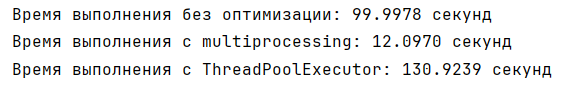

### 2.4.1. Пример №3 (Дополнительный)

Вспомним оптимизацию вычислений используя cupu:

In [ ]:
import time
import numpy as np

# Попытка импортировать cupy
try:
    import cupy as cp
    use_cuda = cp.is_available()
except ImportError:
    use_cuda = False

# use_cuda = False

def process_on_cpu(data):
    # Умножение матриц на CPU с использованием numpy
    return np.dot(data, data)

def process_on_gpu(data):
    # Умножение матриц на GPU с использованием cupy
    data_gpu = cp.asarray(data)
    result_gpu = cp.dot(data_gpu, data_gpu)
    return cp.asnumpy(result_gpu)

# Функция для замера времени выполнения
def measure_time(func, data):
    start_time = time.time()
    result = func(data)
    end_time = time.time()
    print(f"Время выполнения {func.__name__}: {end_time - start_time} секунд")
    # return result

# Данные для обработки
data = np.random.rand(1000, 1000)

# Выбор функции обработки в зависимости от доступности CUDA
if use_cuda:
    print("CUDA доступна. Используем GPU для обработки.")
    process_data = process_on_gpu
else:
    print("CUDA не доступна. Используем CPU для обработки.")
    process_data = process_on_cpu

# Замер скорости выполнения
measure_time(process_data, data)

CUDA доступна. Используем GPU для обработки.


ImportError: libcublas.so.13: cannot open shared object file: No such file or directory

# Практическая часть

Реализуем эффективное программное решение прямой геодезической задачи

- Входные данные:
  - csv-файл с параметрами (Xa, Ya, d, alpha)

- Выходные данные (опционально):
  - csv-файл с вычесленными параметрами (dX, dY, Xb, Yb)
  - xlsx-файл с вычесленными параметрами (dX, dY, Xb, Yb)
  - DataFrame с вычесленными параметрами (dX, dY, Xb, Yb)


## 1. Генератор синтетического набора входных данных

In [ ]:
import random
import csv
import numpy as np
from openpyxl import Workbook

def generate_data(filename, num_files=1, num_records_range=(100, 200),
                  Xa_range=(1100, 10000), Ya_range=(1100, 10000),
                  d_range=(1, 1500), alpha_range=(1, 360), save_xlsx=False):

    for i in range(num_files):
        num_records = random.randint(*num_records_range)

        # Создание массивов NumPy
        Xa = np.random.uniform(*Xa_range, size=num_records)
        Ya = np.random.uniform(*Ya_range, size=num_records)
        d = np.random.uniform(*d_range, size=num_records)
        alpha = np.random.uniform(*alpha_range, size=num_records)

        data = np.column_stack((Xa, Ya, d, alpha))

        file_extension = ".csv" # По умолчанию сохраняем в формате CSV
        if save_xlsx:
            file_extension = ".xlsx" # Если указано сохранение в XLSX

        if i > 0:
            full_filename = f"{filename}_{i}{file_extension}" # Добавляем индекс к имени файла
        else:
            full_filename = f"{filename}{file_extension}"

        if save_xlsx:
            wb = Workbook()
            ws = wb.active
            ws.append(["Xa", "Ya", "d", "alpha"])
            ws.append(data)
            wb.save(full_filename)
        else:
            with open(full_filename, 'w', newline='') as csvfile:
                writer = csv.writer(csvfile)
                writer.writerow(["Xa", "Ya", "d", "alpha"])
                writer.writerows(data)

        print(f"Данные сгенерированы и сохранены в {full_filename}")

In [ ]:
generate_data("big_data", num_files=1, num_records_range=(10000000, 15000000))
generate_data("my_data", num_files=5, num_records_range=(10000, 15000))

Данные сгенерированы и сохранены в big_data.csv
Данные сгенерированы и сохранены в my_data.csv
Данные сгенерированы и сохранены в my_data_1.csv
Данные сгенерированы и сохранены в my_data_2.csv
Данные сгенерированы и сохранены в my_data_3.csv
Данные сгенерированы и сохранены в my_data_4.csv


## 2. Функция-генератор для последовательного считывания входных данных

In [ ]:
import os
import pandas as pd

def process_csv(path, chunk_size=1000):
    """
    Обрабатывает все CSV файлы в папке или один CSV файл и возвращает ограниченный набор данных.

    Args:
        path (str): Путь к папке с CSV файлами или к одному CSV файлу.
        chunk_size (int, optional): Количество возвращаемых строк. По умолчанию 1000.

    Yields:
        pd.DataFrame: Часть данных из каждого CSV файла.
    """
    if os.path.isdir(path):
        # Обрабатываем все CSV файлы в папке
        for filename in os.listdir(path):
            if filename.lower().endswith(".csv"):
                file_path = os.path.join(path, filename)
                first_row = pd.read_csv(file_path, nrows=1, header=None)
                if first_row.applymap(lambda x: isinstance(x, (int, float))).all().all():
                    header_value = None
                else:
                    header_value = 0
                for chunk in pd.read_csv(file_path, chunksize=chunk_size, header=header_value):
                    yield chunk.reset_index(drop=True)
    elif os.path.isfile(path) and path.lower().endswith(".csv"):
        # Обрабатываем один CSV файл
        first_row = pd.read_csv(path, nrows=1, header=None)
        if first_row.applymap(lambda x: isinstance(x, (int, float))).all().all():
            header_value = None
        else:
            header_value = 0
        for chunk in pd.read_csv(path, chunksize=chunk_size, header=header_value):
            yield chunk.reset_index(drop=True)
    else:
        raise ValueError("Недопустимый путь к файлу или папке.")

In [ ]:
# Пример использования
path = "/content/my_data_1.csv"
csv_gen = process_csv(path, 100)
# for data_chunk in csv_gen:
#     print(data_chunk.head())
next(csv_gen)

/tmp/ipykernel_5189/3506588918.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  if first_row.applymap(lambda x: isinstance(x, (int, float))).all().all():


,Xa,Ya,d,alpha
0,6492.832913,2450.210951,318.372286,120.936007
1,2360.363473,4441.980337,1301.161519,203.354640
2,2192.578449,2675.844272,1458.821087,157.338781
3,1992.591431,6126.195294,1124.774827,118.123422
4,2909.886060,3480.336667,886.083920,231.898128
...,...,...,...,...
95,9962.599759,9007.729318,1091.621933,28.320822
96,1204.252423,8119.354104,894.746519,178.940458
97,8684.682335,5023.435046,562.647935,197.527796
98,1383.134235,5151.717333,525.027436,10.822152


## 3. Реализация функции для решения прямой геодезической задачи

### 2.1. Базовая реализация

In [ ]:
import math
import pandas as pd

def direct_task(df):
    # Инициализируем списки для хранения результатов
    dX = []
    dY = []
    Xb = []
    Yb = []

    # Итерируем по каждой строке в датафрейме
    for index, row in df.iterrows():
        # Извлекаем значения из строки
        Xa = float(row['Xa'])
        Ya = float(row['Ya'])
        d = float(row['d'])
        alpha = float(row['alpha'])

        # Вычисляем dX и dY с помощью math
        dX.append(d * math.cos(math.radians(alpha)))
        dY.append(d * math.sin(math.radians(alpha)))

        # Вычисляем Xb и Yb
        Xb.append(Xa + dX[-1])
        Yb.append(Ya + dY[-1])

    # Создаем новый датафрейм с результатами
    result_df = pd.DataFrame({
        'dX': dX,
        'dY': dY,
        'Xb': Xb,
        'Yb': Yb
    })

    return result_df

In [ ]:
sample_df = pd.DataFrame({
    'Xa': [25.0, 2.0, 3.0],
    'Ya': [140.0, 5.0, 6.0],
    'd': [124.0, 8.0, 9.0],
    'alpha': [46.97, 60.0, 30.0]
})

result = direct_task(sample_df)
print(result)

          dX         dY          Xb          Yb
0  84.615269  90.643567  109.615269  230.643567
1   4.000000   6.928203    6.000000   11.928203
2   7.794229   4.500000   10.794229   10.500000


### 2.2. Оптимальная реализация с векторизацией вычислений

In [ ]:
import numpy as np
import pandas as pd

def direct_task(df):
    try:
        # Извлекаем значения из колонок датафрейма
        Xa = df['Xa'].astype(float)
        Ya = df['Ya'].astype(float)
        d = df['d'].astype(float)
        alpha = df['alpha'].astype(float)

        # Вычисляем dX и dY с помощью NumPy
        dX = d * np.cos(np.radians(alpha))
        dY = d * np.sin(np.radians(alpha))

        # Вычисляем Xb и Yb
        Xb = Xa + dX
        Yb = Ya + dY

        # Создаем новый датафрейм с результатами
        result_df = pd.DataFrame({
            'dX': dX,
            'dY': dY,
            'Xb': Xb,
            'Yb': Yb
        })

        return result_df

    except:
        return None


In [ ]:
sample_df = pd.DataFrame({
    'Xa': [25.0, 2.0, 3.0],
    'Ya': [140.0, 5.0, 6.0],
    'd': [124.0, 8.0, 9.0],
    'alpha': [46.97, 60.0, 30.0]
})

result = direct_task(sample_df)
print(result)

          dX         dY          Xb          Yb
0  84.615269  90.643567  109.615269  230.643567
1   4.000000   6.928203    6.000000   11.928203
2   7.794229   4.500000   10.794229   10.500000


### 2.3. Оптимальная реализация с векторизацией вычислений и их выполнением на GPU

In [ ]:
import pandas as pd
import cupy as cp

def direct_task(df):
    try:
        # Извлекаем значения из колонок датафрейма
        Xa = cp.asarray(df['Xa'].astype(float))
        Ya = cp.asarray(df['Ya'].astype(float))
        d = cp.asarray(df['d'].astype(float))
        alpha = cp.asarray(df['alpha'].astype(float))

        # Вычисляем dX и dY с помощью CuPy
        dX = d * cp.cos(cp.radians(alpha))
        dY = d * cp.sin(cp.radians(alpha))

        # Вычисляем Xb и Yb
        Xb = Xa + dX
        Yb = Ya + dY

        # Создаем новый датафрейм с результатами
        result_df = pd.DataFrame({
            'dX': cp.asnumpy(dX),
            'dY': cp.asnumpy(dY),
            'Xb': cp.asnumpy(Xb),
            'Yb': cp.asnumpy(Yb)
        })

        return result_df

    except:
        return None

In [ ]:
sample_df = pd.DataFrame({
    'Xa': [25.0, 2.0, 3.0],
    'Ya': [140.0, 5.0, 6.0],
    'd': [124.0, 8.0, 9.0],
    'alpha': [46.97, 60.0, 30.0]
})

result = direct_task(sample_df)
print(result)

          dX         dY          Xb          Yb
0  84.615269  90.643567  109.615269  230.643567
1   4.000000   6.928203    6.000000   11.928203
2   7.794229   4.500000   10.794229   10.500000


## 4. Многопоточная и многопроцессорная оптимизация. Сравнение и выбор оптимального варианта

In [ ]:
import math
import multiprocessing as mp
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
import time


def split_dataframe(df, num_chunks):
    if df.empty:
        return [df.iloc[0:0].copy()]
    num_chunks = max(1, min(num_chunks, len(df)))
    chunk_size = math.ceil(len(df) / num_chunks)
    return [df.iloc[i:i + chunk_size].copy() for i in range(0, len(df), chunk_size)]


def normalize_results(result_list):
    frames = []
    for result in result_list:
        if result is None:
            continue
        if isinstance(result, pd.DataFrame):
            frames.append(result)
        else:
            frames.append(pd.DataFrame(result))
    return frames


def parallel_processing(df, proc_fun, num_processes=None, use_multiprocessing=False):
    if num_processes is None:
        num_processes = max(1, min(mp.cpu_count(), len(df) if len(df) > 0 else 1))

    df_split = split_dataframe(df, num_processes)

    if use_multiprocessing:
        start_method = "fork" if "fork" in mp.get_all_start_methods() else "spawn"
        ctx = mp.get_context(start_method)
        with ctx.Pool(processes=len(df_split)) as pool:
            result_list = pool.map(proc_fun, df_split)
    else:
        with ThreadPoolExecutor(max_workers=len(df_split)) as pool:
            result_list = list(pool.map(proc_fun, df_split))

    frames = normalize_results(result_list)

    if not frames:
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)


if __name__ == "__main__":
    df = pd.read_csv("/content/big_data.csv")

    start_time = time.time()
    result_df_direct = direct_task(df.copy())
    end_time = time.time()
    direct_time = end_time - start_time
    print(f"Время выполнения без multiprocessing: {direct_time:.4f} секунд")

    start_time = time.time()
    result_df_multiprocessing = parallel_processing(
        df.copy(),
        proc_fun=direct_task,
        use_multiprocessing=True
    )
    end_time = time.time()
    parallel_time = end_time - start_time
    print(f"Время выполнения с multiprocessing: {parallel_time:.4f} секунд")

    start_time = time.time()
    result_df_threadpoolexecutor = parallel_processing(
        df.copy(),
        proc_fun=direct_task,
        use_multiprocessing=False
    )
    end_time = time.time()
    threadpoolexecutor_time = end_time - start_time
    print(f"Время выполнения с ThreadPoolExecutor: {threadpoolexecutor_time:.4f} секунд")

KeyboardInterrupt: 

## 5. Функция для последовательного экспорта выходных данных

In [ ]:
import pandas as pd

def process_and_save_with_function(generator, processing_function=None, output_file='output.csv', save_xlsx=False):
    """
    Обрабатывает данные из генератора с помощью указанной функции и сохраняет результаты в CSV или XLSX файл.

    Args:
        generator: Генератор, возвращающий pd.DataFrame.
        output_file (str): Имя файла для сохранения результатов.
        save_xlsx (bool, optional): Сохранять в формате XLSX (True) или CSV (False). По умолчанию False.
        processing_function (function, optional): Функция для обработки данных из генератора. Должна принимать pd.DataFrame и возвращать pd.DataFrame.
    """
    header_value = None
    first_chunk = next(generator, None)
    if first_chunk is not None:
        if processing_function:
            first_chunk = processing_function(first_chunk)
        if save_xlsx:
            header_value = 0
            wb = pd.ExcelWriter(output_file, engine='openpyxl')
            first_chunk.to_excel(wb, sheet_name='Sheet1', index=False, header=header_value)
        else:
            # Если нет заголовков, заполняем первую строку цифрами
            if first_chunk.columns.empty:
                first_chunk.columns = range(1, len(first_chunk.columns) + 1)
            first_chunk.to_csv(output_file, index=False, header=True)
        for chunk in generator:
            if processing_function:
                chunk = processing_function(chunk)
            if save_xlsx:
                chunk.to_excel(wb, sheet_name='Sheet1', index=False, header=header_value)
            else:
                chunk.to_csv(output_file, mode='a', index=False, header=False)  # Добавляем данные без заголовков
        if save_xlsx:
            wb.save()
        # print(f"Результаты сохранены в файл {output_file}")
    else:
        print("Нет данных для обработки.")

In [ ]:
def measure_time(func, args):
    start = time.time()
    func(*args)
    end = time.time()
    return end - start

# Запуск функции с разными методами и измерение времени

path = "/content/big_data.csv"

generator = process_csv(path, 1000000)
processing_function = direct_task
sequential_time = measure_time(process_and_save_with_function, args=(generator, processing_function))

print(f"Время  выполнения: {sequential_time:.10f} секунд")

## Выполним те же действия без использования генераторов:

In [ ]:
start_time = time.time()
sample_df = pd.read_csv("/content/big_data.csv")

result = direct_task(sample_df)
result.to_csv("output_file.csv", index=False, header=True)
end_time = time.time()
print(f"Время выполнения: {end_time - start_time} секунд")

# result.head(15)

In [ ]:
del sample_df
del result

# Комплексное задание №1.

### Ссылка на алгоритм вычисления и пример : https://clck.ru/39aKXC

## **Ход выполнения работы:**

## 1. Напишите функцию для формирования синтетического набора входных данных

Требования к входным данным:

- excel-таблицы или csv-файлы (опционально)
- первая строка содержит заголовки столбцов
- данные в столбцах - значения B (широты) и L (долготы)

Пример:

| B | L |
|---|---|
| 56.4532 | 37.5432 |
| 45.6789 | 12.3456 |
| -34.5678 | 98.7654 |
| 78.9012 | -56.7890 |
| 23.4567 | 89.0123 |
| -12.3456 | 45.6789 |
| 67.8901 | -23.4567 |
| 34.5678 | 78.9012 |
| -98.7654 | 34.5678 |
| 12.3456 | -98.7654 |

**Примечание:**

* Эта таблица содержит 10 случайных значений широты и долготы
* Широта может быть от -90° до 90°
* Долгота может быть от -180° до 180°

In [1]:
import random
import csv
import numpy as np
from openpyxl import Workbook

def generate_data(filename, num_records=100, B_range=(-90, 90),
                  L_range=(-180, 180), save_xlsx=False):
  #B = np.random.uniform(*B_range, size=num_records)
  B = np.array([58.5])
  L = np.array ([37.5])
  #L = np.random.uniform(*L_range, size=num_records)

  data = np.column_stack((B, L))

  file_extension = ".csv"
  if save_xlsx:
    file_extension = ".xlsx"

  if save_xlsx:
    wb = Workbook()
    ws = wb.active
    ws.append(["B", "L"])
    ws.append(data)
    wb.save(f"{filename}{file_extension}")
  else:
    with open(f"{filename}{file_extension}", 'w', newline='') as csvfile:
      writer = csv.writer(csvfile)
      writer.writerow(["B", "L"])
      writer.writerows(data)

  print(f"Данные сгенерированы и сохранены в {filename}{file_extension}")

generate_data("my_data")

Данные сгенерированы и сохранены в my_data.csv


In [2]:
generate_data("big_data", num_records=10000)

Данные сгенерированы и сохранены в big_data.csv


## 2. Напишите функцию-генератор для последовательного считывания данных из входного файла (csv-файл, excel-таблица)

- Функция принимает на вход путь к файлу и количество строк, которые необходимо возвращать каждую итерацию. Сама функция последовательно возвращает указанное Вами количество строк, до тех пор, пока они не закончатся в этом файле

- Возвращает DataFrame, с указанным количеством строк

In [3]:
import os
import pandas as pd

def process_csv(path, chunk_size=1000):
    if path.lower().endswith(".csv"):
        first_row = pd.read_csv(path, nrows=1, header=None)
        if first_row.applymap(lambda x: isinstance(x, (int, float))).all().all():
            header_value = None
        else:
            header_value = 0
        for chunk in pd.read_csv(path, chunksize=chunk_size, header=header_value):
            yield chunk.reset_index(drop=True)
    else:
        raise ValueError("Недопустимый путь к файлу или папке.")

path = "/content/my_data.csv"
csv_gen = process_csv(path, 5)
next(csv_gen)

/tmp/ipykernel_3872/1863807731.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  if first_row.applymap(lambda x: isinstance(x, (int, float))).all().all():


,B,L
0,58.5,37.5


## 3. Напишите оптимальную функцию для реализации алгоритма

- Принимает на вход DataFrame с входными данными
- Возвращает DataFrame с выходными данными (вычесленными параметрами)
- Вычисления должны быть реализованы средствами numpy
- Добавить опционально возможность вычисления на CUDA GPU

### 3.1. Оптимальная реализация с векторизацией вычислений

In [4]:
import numpy as np
import pandas as pd

def direct_task(df, a=6378136, alpha=0.003352804):
    try:
        B = np.radians(np.asarray(df['B'].values))
        L = np.radians(np.asarray(df['L'].values))

        b = a * (1 - alpha)
        e2 = alpha * (2 - alpha)
        U = np.arctan(np.sqrt(1 - e2) * np.tan(B))

        x = a * np.cos(U) * np.cos(L)
        y = a * np.cos(U) * np.sin(L)
        z = b * np.sin(U)

        result_df = pd.DataFrame({
            'x': x,
            'y': y,
            'z': z
        })

        return result_df

    except:
        return None

sample_df = pd.read_csv('my_data.csv')

result = direct_task(sample_df)
result

,x,y,z
0,2.650360e+06,2.033693e+06,5.415042e+06


### 3.2. Оптимальная реализация с векторизацией вычислений и их выполнением на GPU

In [5]:
!nvidia-smi

Mon Jun  8 20:08:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
!pip install cupy-cuda13x

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 12.4 MB/s eta 0:00:00


In [7]:
import pandas as pd
import cupy as cp

def direct_task_gpu(df, a=6378136.0, alpha=0.003352804):
    B = cp.radians(cp.asarray(df['B'].values))
    L = cp.radians(cp.asarray(df['L'].values))

    b = a * (1 - alpha)
    e2 = alpha * (2 - alpha)
    U = cp.arctan(cp.sqrt(1 - e2) * cp.tan(B))

    x = a * cp.cos(U) * cp.cos(L)
    y = a * cp.cos(U) * cp.sin(L)
    z = b * cp.sin(U)
    result_df_cp = pd.DataFrame({
        'x': cp.asnumpy(x),
        'y': cp.asnumpy(y),
        'z': cp.asnumpy(z)
    })

    return result_df_cp

sample_df = pd.read_csv('my_data.csv')

result_gpu = direct_task_gpu(sample_df)
result_gpu

/usr/local/lib/python3.12/dist-packages/cupy/_environment.py:670: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy-cuda12x, cupy-cuda13x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


,x,y,z
0,2.650360e+06,2.033693e+06,5.415042e+06


## 4. Оптимизируйте вычисления, используя Multiprocessing, ThreadPoolExecutor и CuPy

- Сравните их по скорости. Выведите время выполнения с их использованием и без их использования
- Выберите оптимальный вариант оптимизации на CPU

In [8]:
import multiprocessing
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
import numpy as np
import time

def parallel_processing(df, num_processes=multiprocessing.cpu_count(), use_multiprocessing=False, proc_fun = direct_task):
    df_split = np.array_split(df, num_processes)

    if use_multiprocessing:
        with multiprocessing.Pool(processes=num_processes) as pool:
            result_list = pool.map(proc_fun, df_split)
    else:
        with ThreadPoolExecutor(max_workers=num_processes) as pool:
            result_list = pool.map(proc_fun, df_split)

    final_df = pd.concat([result for result in result_list if result is not None])

    return final_df

if __name__ == "__main__":
    df = pd.read_csv("/content/my_data.csv")

    start_time = time.time()
    result_df_direct = direct_task(df)
    end_time = time.time()
    direct_time = end_time - start_time
    print(f"Время выполнения без multiprocessing: {direct_time:.4f} секунд")

    start_time = time.time()
    result_df_multiprocessing = parallel_processing(df.copy(), use_multiprocessing=True)
    end_time = time.time()
    parallel_time = end_time - start_time
    print(f"Время выполнения с multiprocessing: {parallel_time:.4f} секунд")

    start_time = time.time()
    result_df_threadpoolexecutor = parallel_processing(df.copy(), use_multiprocessing=False)
    end_time = time.time()
    threadpoolexecutor_time = end_time - start_time
    print(f"Время выполнения с ThreadPoolExecutor: {threadpoolexecutor_time:.4f} секунд")

    start_time = time.time()
    result_df_gpu = direct_task_gpu(df)
    end_time = time.time()
    gpu_time = end_time - start_time
    print(f"Время выполнения с CuPy (GPU): {gpu_time:.4f} секунд")

Время выполнения без multiprocessing: 0.0004 секунд


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Время выполнения с multiprocessing: 0.0491 секунд
Время выполнения с ThreadPoolExecutor: 0.0026 секунд
Время выполнения с CuPy (GPU): 0.0015 секунд


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


## 5. Напишите функцию для для последовательного экспорта выходных данных в книгу Excel

- На каждую пару входных данных (строку таблицы входных данных) в книге должен формироваться отдельный лист с расчетами по [образцу](https://clck.ru/39aKXC)

In [9]:
!pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.7 MB/s eta 0:00:00


In [10]:
df_input = pd.read_csv("my_data.csv")
a = 6378136.0
alpha = 0.003352804
with pd.ExcelWriter("result.xlsx", engine='xlsxwriter') as writer:
    workbook = writer.book
    header_format = workbook.add_format({'bold': True, 'bg_color': '#B7D2B6', 'border': 1})
    data_format = workbook.add_format({'border': 1})
    for i, row in df_input.iterrows():
        sheet_name = f"Sheet_{i+1}"
        worksheet = workbook.add_worksheet(sheet_name)

        B = np.radians(row['B'])
        L = np.radians(row['L'])
        b = a * (1 - alpha)
        e2 = alpha * (2 - alpha)
        e12 = e2 / (1 - e2)
        c = a ** 2 / b
        W2 = 1 - e2 * np.sin(B) ** 2
        V2 = 1 + e12 * np.cos(B) ** 2
        M = c / np.sqrt(V2) ** 3
        N1 = c / np.sqrt(V2)
        N2 = a / np.sqrt(W2)
        N3 = a / np.sqrt(1 - e2 * np.sin(B) ** 2)
        Rmid = np.sqrt(M * N1)
        tan_U = np.sqrt(1 - e2) * np.tan(B)
        U = np.arctan(tan_U)
        x = a * np.cos(U) * np.cos(L)
        y = a * np.cos(U) * np.sin(L)
        z = b * np.sin(U)

        data1 = [
            ["Дано", "Эллипсоид ПЗ-90"],
            ["Полуось a", a],
            ["Полуось alpha", alpha],
            ["Широта B", row['B']],
            ["Долгота L", row['L']]
        ]
        data2 = [
            ["Формулы", "Эллипсоид ПЗ-90"],
            ["b = a(1-α)", b],
            ["е² = α(2-α)", e2],
            ["(e¹)²=e²/(1-e²)", e12],
            ["c=a²/b", c]
        ]
        data3 = [
            ["Формулы", "Эллипсоид ПЗ-90"],
            ["Wi²=(1-e²sin²Bi)", W2],
            ["Vi²=(1+(e¹)²cos²Bi)", V2]
        ]
        data4 = [
            ["Формулы", "Эллипсоид ПЗ-90"],
            ["M=c/V³", M],
            ["N=c/V", N1],
            ["N=a/W", N2],
            ["N=a/√(1-e²sin²B)", N3],
            ["Rср.=√MN", Rmid]
        ]
        data5 = [
            ["Формулы", "Эллипсоид ПЗ-90"],
            ["tgU = √(1-e²)*tgB", tan_U],
            ["x = a*cosUcosL", x],
            ["y = a*cosUsinL", y],
            ["z = b*sinU", z]
        ]

        for r_idx, row_data in enumerate(data1):
            fmt = header_format if r_idx == 0 else data_format
            worksheet.write_row(r_idx, 0, row_data, fmt)
        start_row_t2 = 6
        for r_idx, row_data in enumerate(data2):
            fmt = header_format if r_idx == 0 else data_format
            worksheet.write_row(start_row_t2 + r_idx, 0, row_data, fmt)
        start_row_t3 = 12
        for r_idx, row_data in enumerate(data3):
            fmt = header_format if r_idx == 0 else data_format
            worksheet.write_row(start_row_t3 + r_idx, 0, row_data, fmt)
        start_row_t4 = 16
        for r_idx, row_data in enumerate(data4):
            fmt = header_format if r_idx == 0 else data_format
            worksheet.write_row(start_row_t4 + r_idx, 0, row_data, fmt)
        start_row_t5 = 23
        for r_idx, row_data in enumerate(data5):
            fmt = header_format if r_idx == 0 else data_format
            worksheet.write_row(start_row_t5 + r_idx, 0, row_data, fmt)

        worksheet.set_column(0, 1, 25)

print("Файл result.xlsx успешно создан!")

Файл result.xlsx успешно создан!


## Выполните вычисления, сравните скорости на большом массиве входных данных

In [11]:
import multiprocessing
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
import numpy as np
import time
import cupy as cp

def direct_task(df, a=6378136.0, alpha=0.003352804):
        B = np.radians(np.asarray(df['B'].values))
        L = np.radians(np.asarray(df['L'].values))

        b = a * (1 - alpha)
        e2 = alpha * (2 - alpha)
        U = np.arctan(np.sqrt(1 - e2) * np.tan(B))

        x = a * np.cos(U) * np.cos(L)
        y = a * np.cos(U) * np.sin(L)
        z = b * np.sin(U)

        return pd.DataFrame({'x': x, 'y': y, 'z': z})


def gpu(df, a=6378136.0, alpha=0.003352804):
      B = cp.radians(cp.asarray(df['B'].values))
      L = cp.radians(cp.asarray(df['L'].values))

      b = a * (1 - alpha)
      e2 = alpha * (2 - alpha)
      U = cp.arctan(cp.sqrt(1 - e2) * cp.tan(B))
      x = a * cp.cos(U) * cp.cos(L)
      y = a * cp.cos(U) * cp.sin(L)
      z = b * cp.sin(U)

      return pd.DataFrame({
          'x': cp.asnumpy(x),
          'y': cp.asnumpy(y),
          'z': cp.asnumpy(z)})


def parallel_processing(df, num_processes=multiprocessing.cpu_count(), use_multiprocessing=False, proc_fun=direct_task):
    df_split = np.array_split(df, num_processes)

    if use_multiprocessing:
        with multiprocessing.Pool(processes=num_processes) as pool:
            result_list = pool.map(proc_fun, df_split)
    else:
        with ThreadPoolExecutor(max_workers=num_processes) as pool:
            result_list = list(pool.map(proc_fun, df_split))
    final_df = pd.concat([result for result in result_list if result is not None])
    return final_df

if __name__ == "__main__":
    df = pd.read_csv("big_data.csv")

    start_time = time.time()
    result_df_direct = direct_task(df)
    print(f"Время выполнения без multiprocessing: {time.time() - start_time:.4f} секунд")

    start_time = time.time()
    result_df_multiprocessing = parallel_processing(df.copy(), use_multiprocessing=True, proc_fun=direct_task)
    print(f"Время выполнения с multiprocessing: {time.time() - start_time:.4f} секунд")

    start_time = time.time()
    result_df_threadpoolexecutor = parallel_processing(df.copy(), use_multiprocessing=False, proc_fun=direct_task)
    print(f"Время выполнения с ThreadPoolExecutor: {time.time() - start_time:.4f} секунд")

    start_time = time.time()
    result_df_gpu = gpu(df)
    print(f"Время выполнения с CuPy (GPU): {time.time() - start_time:.4f} секунд")

Время выполнения без multiprocessing: 0.0005 секунд


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Время выполнения с multiprocessing: 0.1206 секунд
Время выполнения с ThreadPoolExecutor: 0.0130 секунд
Время выполнения с CuPy (GPU): 0.0087 секунд


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)



- Выведите первую строку таблицы **входных** данных


In [12]:
first_row = pd.read_csv("/content/big_data.csv", nrows=1)
print(first_row.head(1))

      B     L
0  58.5  37.5


- Выведите содержимое первой страницы таблицы **выходных** данных

In [13]:
table = pd.read_excel('result.xlsx', sheet_name='Sheet_1', header=None)
a_t, a_ = table.iloc[1, 0], table.iloc[1, 1]
alpha_t, alpha_ = table.iloc[2, 0], table.iloc[2, 1]
B_t, B_ = table.iloc[3, 0], table.iloc[3, 1]
L_t, L_ = table.iloc[4, 0], table.iloc[4, 1]
b_t, b_ = table.iloc[7, 0], table.iloc[7, 1]
e2_t, e2_ = table.iloc[8, 0], table.iloc[8, 1]
e12_t, e12_ = table.iloc[9, 0], table.iloc[9, 1]
c_t, c_ = table.iloc[10, 0], table.iloc[10, 1]
W2_t, W2_ = table.iloc[13, 0], table.iloc[13, 1]
V2_t, V2_ = table.iloc[14, 0], table.iloc[14, 1]
M_t, M_ = table.iloc[17, 0], table.iloc[17, 1]
N1_t, N1_ = table.iloc[18, 0], table.iloc[18, 1]
N2_t, N2_ = table.iloc[19, 0], table.iloc[19, 1]
N3_t, N3_ = table.iloc[20, 0], table.iloc[20, 1]
R_t, R_ = table.iloc[21, 0], table.iloc[21, 1]
tgU_t, tgU_ = table.iloc[24, 0], table.iloc[24, 1]
x_t, x_ = table.iloc[25, 0], table.iloc[25, 1]
y_t, y_ = table.iloc[26, 0], table.iloc[26, 1]
z_t, z_ = table.iloc[27, 0], table.iloc[27, 1]

result_ = pd.DataFrame({
    a_t: [a_],
    alpha_t: [alpha_],
    B_t: [B_],
    L_t: [L_],
    b_t: [b_],
    e2_t: [e2_],
    e12_t: [e12_],
    c_t: [c_],
    W2_t: [W2_],
    V2_t: [V2_],
    M_t: [M_],
    N1_t: [N1_],
    N2_t: [N2_],
    N3_t: [N3_],
    R_t: [R_],
    tgU_t: [tgU_],
    x_t: [x_],
    y_t: [y_],
    z_t: [z_]
}).transpose()
print(result_)

                                0
Полуось a            6.378136e+06
Полуось alpha        3.352804e-03
Широта B             5.850000e+01
Долгота L            3.750000e+01
b = a(1-α)           6.356751e+06
е² = α(2-α)          6.694367e-03
(e¹)²=e²/(1-e²)      6.739483e-03
c=a²/b               6.399593e+06
Wi²=(1-e²sin²Bi)     9.951332e-01
Vi²=(1+(e¹)²cos²Bi)  1.001840e+00
M=c/V³               6.381971e+06
N=c/V                6.393713e+06
N=a/W                6.393713e+06
N=a/√(1-e²sin²B)     6.393713e+06
Rср.=√MN             6.387840e+06
tgU = √(1-e²)*tgB    1.626380e+00
x = a*cosUcosL       2.650360e+06
y = a*cosUsinL       2.033693e+06
z = b*sinU           5.415042e+06
